# Loss Function Experiments — Multiple Linear Regression

This notebook investigates the squared-error objective used by
Ordinary Least Squares (OLS).

The goal is to understand why the OLS solution produces the
coefficients that minimize the sum of squared residuals.

### Objectives

- Understand residuals
- Implement SSE and MSE from scratch
- Calculate the loss produced by the OLS coefficients
- Perturb model coefficients and observe how the loss changes
- Visualize the effect of coefficient changes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


from src.linear_regression import MultipleLinearRegression

In [3]:
df = pd.read_csv("../data/Advertising.csv")

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = MultipleLinearRegression()

model.fit(X_train, y_train)

In [6]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 2.9790673381227037
Coefficients: [0.04472952 0.18919505 0.00276111]


In [7]:
beta_ols = np.concatenate([[model.intercept_], model.coef_])

beta_ols

array([2.97906734e+00, 4.47295175e-02, 1.89195054e-01, 2.76111434e-03])

## Residuals

A residual is the difference between an observed value and
the value predicted by the model.

eᵢ = yᵢ - ŷᵢ

For all observations:

e = y - ŷ

In [8]:
y_train_pred = model.predict(X_train)

residuals = y_train - y_train_pred

residuals[:10]

79     1.311725
197    0.126623
38     0.044667
24     1.499898
122   -1.895621
195    2.174140
29     1.223254
19     0.457776
143    1.568831
86     0.361029
Name: Sales, dtype: float64

## Sum of Squared Errors

OLS minimizes the Sum of Squared Errors (SSE):

SSE = Σ(yᵢ - ŷᵢ)²

The residuals are squared so that positive and negative errors
do not cancel each other out.

In [9]:
def sse(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2)

In [10]:
ols_sse = sse(y_train, y_train_pred)

print("OLS SSE:", ols_sse)

OLS SSE: 432.8207076930263


In [11]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [12]:
ols_mse = mse(y_train, y_train_pred)

print("OLS MSE:", ols_mse)

OLS MSE: 2.7051294230814142


In [13]:
print("SSE / n:", ols_sse / len(y_train))
print("MSE:", ols_mse)

SSE / n: 2.7051294230814142
MSE: 2.7051294230814142


In [14]:
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train.values]

In [15]:
X_train_b.shape

(160, 4)

In [16]:
y_pred_from_beta = X_train_b @ beta_ols

In [17]:
np.allclose(y_pred_from_beta, y_train_pred)

True

In [18]:
beta_modified = beta_ols.copy()

beta_modified[1] += 5

In [19]:
y_pred_modified = X_train_b @ beta_modified

In [20]:
modified_sse = sse(y_train, y_pred_modified)

print("Original SSE:", ols_sse)
print("Modified SSE:", modified_sse)

Original SSE: 432.8207076930263
Modified SSE: 118351694.0707077


In [21]:
tv_coefficient = beta_ols[1]

tv_values = np.linspace(tv_coefficient - 20, tv_coefficient + 20, 100)

sse_values = []

In [22]:
for tv_beta in tv_values:

    beta_temp = beta_ols.copy()
    beta_temp[1] = tv_beta

    predictions = X_train_b @ beta_temp

    current_sse = sse(y_train, predictions)

    sse_values.append(current_sse)

In [23]:
sse_values = np.array(sse_values)

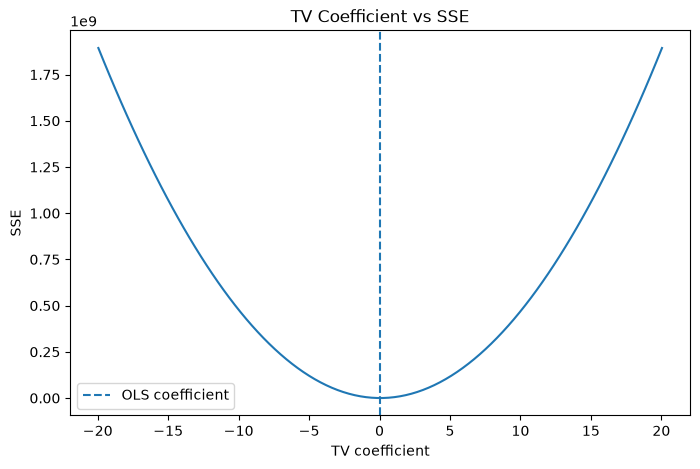

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(tv_values, sse_values)

plt.axvline(
    tv_coefficient,
    linestyle="--",
    label="OLS coefficient"
)

plt.xlabel("TV coefficient")
plt.ylabel("SSE")
plt.title("TV Coefficient vs SSE")

plt.legend()

plt.show()

In [25]:
min_index = np.argmin(sse_values)

print("Experimental coefficient:", tv_values[min_index])
print("OLS coefficient:", tv_coefficient)

Experimental coefficient: -0.15729068455148365
OLS coefficient: 0.04472951746871606


In [26]:
changes = [-10, -5, -2, 0, 2, 5, 10]

results = []

for change in changes:

    beta_temp = beta_ols.copy()
    beta_temp[1] = tv_coefficient + change

    predictions = X_train_b @ beta_temp

    results.append({
        "Change in TV coefficient": change,
        "TV coefficient": beta_temp[1],
        "SSE": sse(y_train, predictions),
        "MSE": mse(y_train, predictions)
    })

loss_experiment = pd.DataFrame(results)

loss_experiment

,Change in TV coefficient,TV coefficient,SSE,MSE
0,-10,-9.95527,4.734055e+08,2.958784e+06
1,-5,-4.95527,1.183517e+08,7.396981e+05
2,-2,-1.95527,1.893663e+07,1.183540e+05
3,0,0.04473,4.328207e+02,2.705129e+00
4,2,2.04473,1.893663e+07,1.183540e+05
5,5,5.04473,1.183517e+08,7.396981e+05
6,10,10.04473,4.734055e+08,2.958784e+06


### Why are we changing one coefficient at a time?

Multiple Linear Regression has several parameters:

β₀, β₁, β₂, β₃

Changing all parameters simultaneously would make this simple
visual experiment difficult to interpret.

By fixing all parameters except one, we can observe how the
loss changes as a single coefficient moves away from its OLS
value.

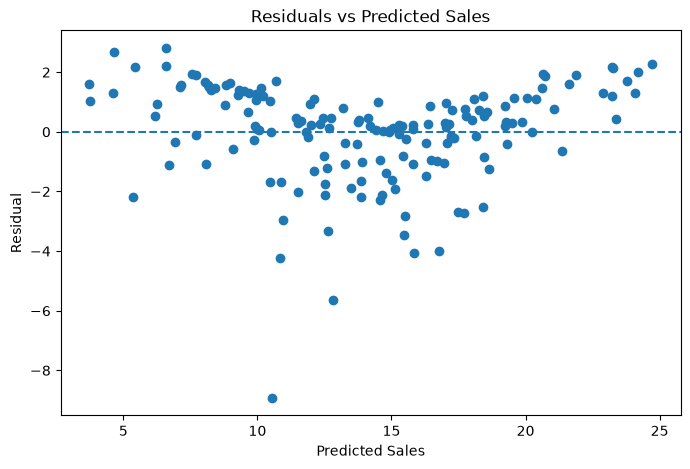

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_train_pred,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sales")

plt.show()

In [28]:
beta_bad = beta_ols.copy()

beta_bad[1] += 30
beta_bad[2] -= 20
beta_bad[3] += 15

In [29]:
y_pred_bad = X_train_b @ beta_bad

In [30]:
print("OLS SSE:", sse(y_train, y_train_pred))
print("Bad model SSE:", sse(y_train, y_pred_bad))

OLS SSE: 432.8207076930263
Bad model SSE: 4258093851.0707073


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "OLS Model",
        "Modified Model"
    ],
    "SSE": [
        sse(y_train, y_train_pred),
        sse(y_train, y_pred_bad)
    ],
    "MSE": [
        mse(y_train, y_train_pred),
        mse(y_train, y_pred_bad)
    ]
})

comparison

,Model,SSE,MSE
0,OLS Model,4.328207e+02,2.705129e+00
1,Modified Model,4.258094e+09,2.661309e+07


## Conclusion

This experiment demonstrated the relationship between
Ordinary Least Squares and the squared-error objective.

Key observations:

- OLS minimizes the sum of squared residuals.
- The OLS coefficient produced the minimum SSE in the
  coefficient experiment.
- Moving a coefficient away from its OLS value increased
  the SSE.
- Squaring residuals prevents positive and negative errors
  from cancelling each other.
- SSE and MSE differ only by a constant factor for a fixed
  dataset, so they have the same minimizing coefficients.

The next notebook will focus on residual analysis and
regression diagnostics.